In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot_2samples

In [2]:
trait_info = pd.read_csv("data/trait_info_supplementary.csv")
trait_info

,UKB_code,Name,ID
0,30290_irnt,High light scatter reticulocyte percentage,7
1,3148_irnt,Heel bone mineral density (BMD),9
2,30180_irnt,Lymphocyte percentage,10
3,102_irnt,"Pulse rate, automated reading",11


In [3]:
ukb_cojo_df = pd.read_csv("data/data15_snp.csv")
ukb_cojo_df.head()

,chr,SNP,bp,refA,x,b,se,p,n,freq_geno,...,mj,loc,xb,blk,ld,a,a_se,z,v,dv
0,1,1:958953:A:G,958953,G,0.373252,0.010131,0.001712,3.255660e-09,359493.0,0.377852,...,0.985132,1000958953,35,1,96.2661,0.011605,0.001725,6.728744,0.000063,0.000001
1,1,1:1039185:C:T,1039185,T,0.049809,-0.018930,0.004078,3.445330e-06,313167.0,0.037739,...,0.987807,1001039185,21,1,19.7073,0.023663,0.004103,5.767476,0.000053,0.000002
2,1,1:1303299:C:T,1303299,T,0.120098,0.013764,0.002559,7.482840e-08,356212.0,0.114681,...,0.995358,1001303299,25,1,166.8290,0.015433,0.002565,6.017398,0.000050,0.000001
3,1,1:2141866:C:T,2141866,T,0.277368,0.016339,0.001855,1.298040e-18,357099.0,0.276270,...,0.984805,1002141866,32,2,153.2490,0.015231,0.001870,8.145979,0.000093,0.000001
4,1,1:3769590:G:C,3769590,C,0.311938,-0.009387,0.001782,1.380850e-07,361621.0,0.688488,...,0.998509,1003769590,33,3,166.5360,0.009896,0.001783,5.549575,0.000042,0.000001


In [4]:
def prepare_sim_data(df):
    df = df[df.freq > 0.01]
    df = df[df.pJ < 5e-8]

    return df["z"]

In [5]:
sim_data = {}
ukb_data = {}

In [6]:
for index, row in trait_info.iterrows():
    sim_data[index] = prepare_sim_data(pd.read_csv(f"data/cojo_result_supplementary/sim_{row["UKB_code"]}_cojo_hit.csv"))
    ukb_data[index] = ukb_cojo_df[ukb_cojo_df["id"] == row["ID"]]["z"]

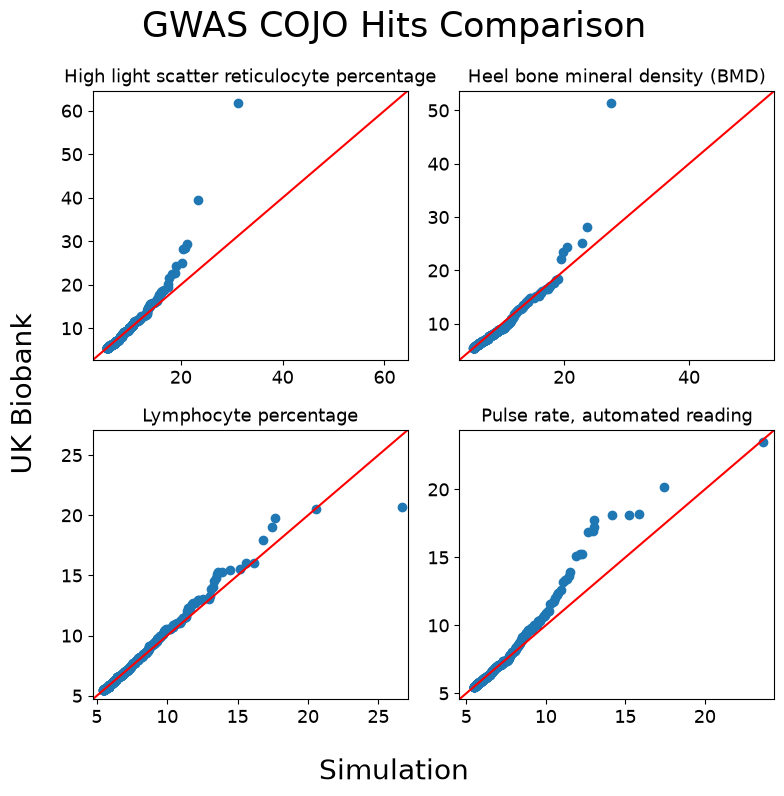

In [7]:
plt.rcParams.update({'font.size': 13})
fig, axes = plt.subplots(2, 2, tight_layout=True, figsize=(8, 8))

index=0
qqplot_2samples(sim_data[index], ukb_data[index], xlabel="", ylabel="", line="45", ax=axes[0,0])
axes[0,0].set_title(trait_info.loc[index]["Name"], size=13)

index=1
qqplot_2samples(sim_data[index], ukb_data[index], xlabel="", ylabel="", line="45", ax=axes[0,1])
axes[0,1].set_title(trait_info.loc[index]["Name"], size=13)

index=2
qqplot_2samples(sim_data[index], ukb_data[index], xlabel="", ylabel="", line="45", ax=axes[1,0])
axes[1,0].set_title(trait_info.loc[index]["Name"], size=13)

index=3
qqplot_2samples(sim_data[index], ukb_data[index], xlabel="", ylabel="", line="45", ax=axes[1,1])
axes[1,1].set_title(trait_info.loc[index]["Name"], size=13)

fig.suptitle("GWAS COJO Hits Comparison", size=25)
fig.supxlabel("Simulation", size=20)
fig.supylabel("UK Biobank", size=20)
plt.savefig("gwas-cojo-hit-comparison-supplementary.pdf")
plt.show()